## 1. Resize 3 images to 224×224 and save them

In [1]:
from PIL import Image
import os

# Folder where resized images will be saved
output_folder = "resized_images"

# Create folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Your actual image filenames
image_files = [
    "image1.jfif",
    "image2.jfif",
    "image3.jfif"
]

# Resize each image to 224x224
for filename in image_files:

    # Load image
    image = Image.open(filename)

    print(f"Original {filename}: {image.size}")

    # Resize
    resized_image = image.resize((224, 224))

    # Save resized image
    output_path = os.path.join(output_folder, filename)
    resized_image.save(output_path)

    print(f"Saved: {output_path}")
    print(f"New size: {resized_image.size}\n")

print("All 3 images resized successfully!")

Original image1.jfif: (237, 148)
Saved: resized_images\image1.jfif
New size: (224, 224)

Original image2.jfif: (148, 148)
Saved: resized_images\image2.jfif
New size: (224, 224)

Original image3.jfif: (151, 148)
Saved: resized_images\image3.jfif
New size: (224, 224)

All 3 images resized successfully!


## 2. Original → grayscale → RGB

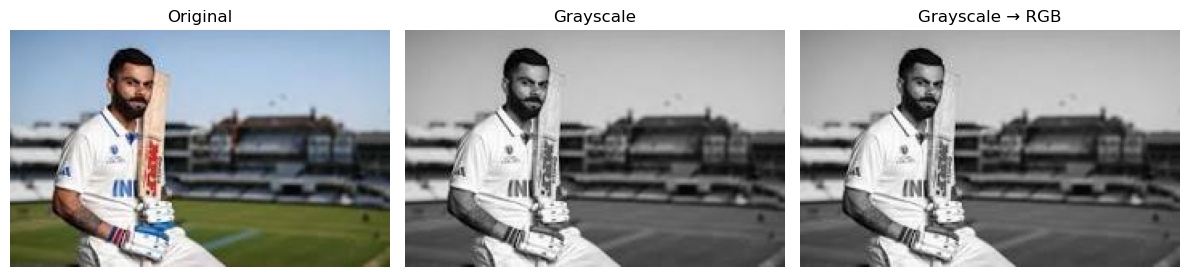

In [3]:
from PIL import Image
import matplotlib.pyplot as plt

# Load colored image
image = Image.open("image1.jfif").convert("RGB")

# Convert to grayscale
gray_image = image.convert("L")

# Convert grayscale back to RGB
rgb_image = gray_image.convert("RGB")

# Display all three
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gray_image, cmap="gray")
plt.title("Grayscale")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(rgb_image)
plt.title("Grayscale → RGB")
plt.axis("off")

plt.tight_layout()
plt.show()

## 3. Generate 4 augmented images

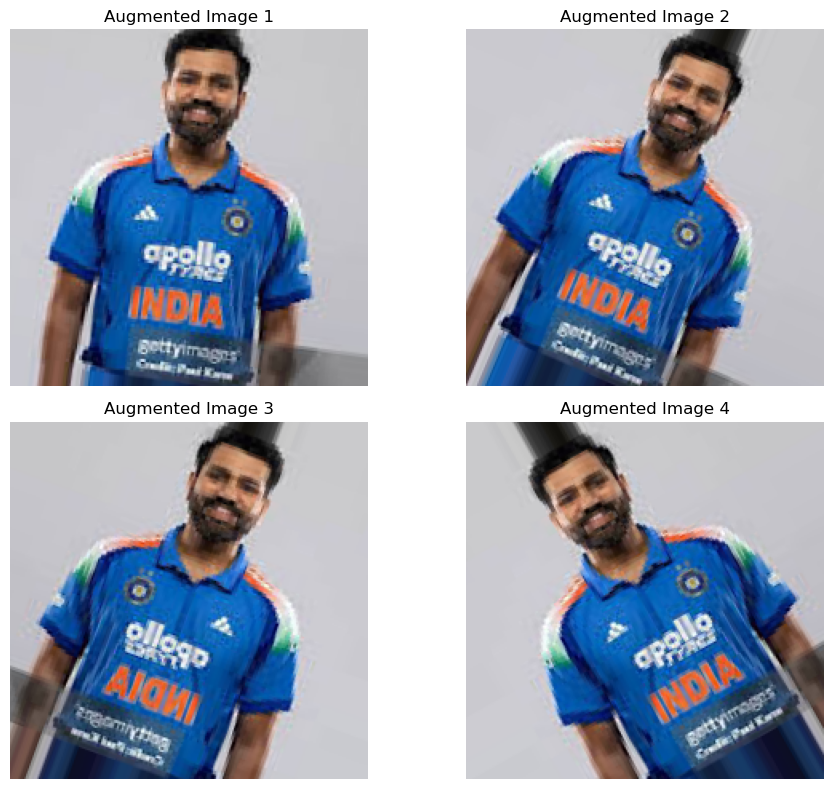

In [5]:
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)
import matplotlib.pyplot as plt
import numpy as np

# Load image
image = load_img("image2.jfif", target_size=(224, 224))

# Convert to NumPy array
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# Create augmentation generator
datagen = ImageDataGenerator(
    rotation_range=30,
    horizontal_flip=True
)

# Generate 4 augmented versions
augmented_images = []

generator = datagen.flow(
    image_array,
    batch_size=1,
    seed=42
)

for i in range(4):
    augmented_image = next(generator)[0].astype("uint8")
    augmented_images.append(augmented_image)

# Display results
plt.figure(figsize=(10, 8))

for i, img in enumerate(augmented_images):
    plt.subplot(2, 2, i + 1)
    plt.imshow(img)
    plt.title(f"Augmented Image {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 4. Increase and decrease brightness by 40%

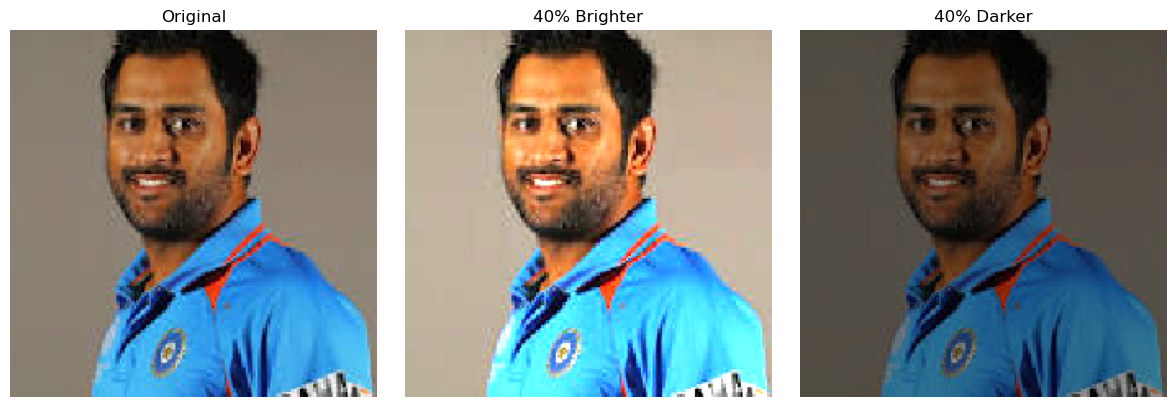

In [7]:
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)
import matplotlib.pyplot as plt
import numpy as np

# Load image
image = load_img("image3.jfif", target_size=(224, 224))
image_array = img_to_array(image)

# Add batch dimension
image_array = np.expand_dims(image_array, axis=0)

# 40% brighter: factor = 1.4
bright_datagen = ImageDataGenerator(
    brightness_range=(1.4, 1.4)
)

# 40% darker: factor = 0.6
dark_datagen = ImageDataGenerator(
    brightness_range=(0.6, 0.6)
)

# Generate bright image
bright_generator = bright_datagen.flow(
    image_array,
    batch_size=1,
    seed=42
)

bright_image = next(bright_generator)[0].astype("uint8")

# Generate dark image
dark_generator = dark_datagen.flow(
    image_array,
    batch_size=1,
    seed=42
)

dark_image = next(dark_generator)[0].astype("uint8")

# Display original, brightened and darkened
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(image_array[0].astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(bright_image)
plt.title("40% Brighter")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(dark_image)
plt.title("40% Darker")
plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Apply shear transformation

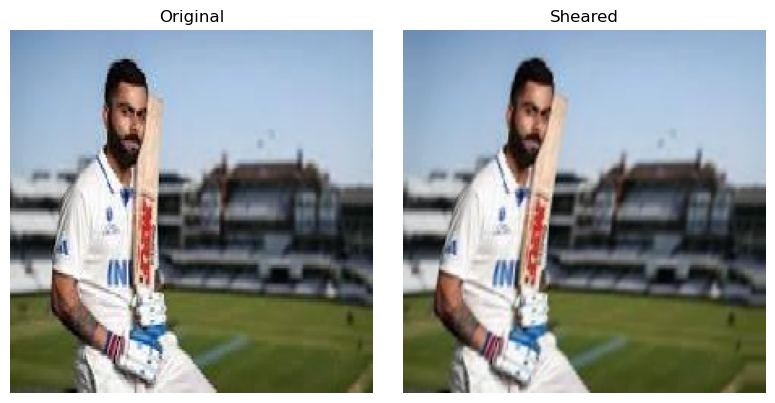

In [8]:
from tensorflow.keras.preprocessing.image import (
    ImageDataGenerator,
    load_img,
    img_to_array
)
import matplotlib.pyplot as plt
import numpy as np

# Load cricket/meme image
image = load_img("image1.jfif", target_size=(224, 224))

# Convert to NumPy array
image_array = img_to_array(image)
image_array = np.expand_dims(image_array, axis=0)

# Create shear augmentation
datagen = ImageDataGenerator(
    shear_range=25
)

# Generate sheared image
generator = datagen.flow(
    image_array,
    batch_size=1,
    seed=42
)

sheared_image = next(generator)[0].astype("uint8")

# Display original and sheared images
plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(image_array[0].astype("uint8"))
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(sheared_image)
plt.title("Sheared")
plt.axis("off")

plt.tight_layout()
plt.show()
